In [8]:
# importing all the neccessary libraries and turning off the unnesseccary warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("✓ Libraries loaded!")

✓ Libraries loaded!


In [2]:
import pandas as pd
import numpy as np

cols = ['event_time', 'event_type', 'product_id', 
        'category_code', 'brand', 'price', 'user_id']

dtypes = {
    'event_type': 'category',
    'category_code': 'category',
    'brand': 'category',
    'product_id': 'int32',
    'user_id': 'int32',
    'price': 'float32'
}

def load_sampled(filename, sample_every=10):
    """Load 1 in every N rows — keeps data distribution intact"""
    chunks = []
    for chunk in pd.read_csv(filename,
                              usecols=cols,
                              dtype=dtypes,
                              chunksize=500_000):
        # Keep every 10th row — still millions of rows, but manageable
        chunks.append(chunk.iloc[::sample_every])
    return pd.concat(chunks, ignore_index=True)

print("Loading October (sampled)...")
df_oct = load_sampled('2019-Oct.csv', sample_every=10)
print(f"✓ Oct: {len(df_oct):,} rows")

print("Loading November (sampled)...")
df_nov = load_sampled('2019-Nov.csv', sample_every=10)
print(f"✓ Nov: {len(df_nov):,} rows")

df = pd.concat([df_oct, df_nov], ignore_index=True)
del df_oct, df_nov

df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

print(f"\n✓ Total rows: {len(df):,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading October (sampled)...
✓ Oct: 4,244,877 rows
Loading November (sampled)...
✓ Nov: 6,750,198 rows

✓ Total rows: 10,995,075
Memory usage: 1924.3 MB


In [3]:
# Fill missing values
df['category_code'] = df['category_code'].fillna('unknown')
df['brand'] = df['brand'].fillna('unknown')

# Extract time features (useful for analysis + Power BI later)
df['date']        = df['event_time'].dt.date
df['month_name']  = df['event_time'].dt.strftime('%b %Y')
df['hour']        = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()

# Extract top-level category from 'electronics.smartphone' → 'electronics'
df['category_top'] = df['category_code'].apply(
    lambda x: x.split('.')[0] if x != 'unknown' else 'unknown'
)

print(f"✓ Clean shape: {df.shape}")
print(f"Months: {df['month_name'].unique()}")

✓ Clean shape: (10995075, 12)
Months: ['Oct 2019' 'Nov 2019']


In [4]:
print("=== EVENT BREAKDOWN ===")
event_counts = df['event_type'].value_counts()
print(event_counts)

print(f"\n=== KEY STATS ===")
print(f"Unique users:      {df['user_id'].nunique():,}")
print(f"Unique products:   {df['product_id'].nunique():,}")
print(f"Unique brands:     {df['brand'].nunique():,}")
print(f"Unique categories: {df['category_top'].nunique():,}")

=== EVENT BREAKDOWN ===
event_type
view        10433730
cart          395467
purchase      165878
Name: count, dtype: int64

=== KEY STATS ===
Unique users:      2,657,873
Unique products:   169,703
Unique brands:     4,059
Unique categories: 14


In [5]:
import os
os.makedirs('processed', exist_ok=True)

df.to_csv('processed/clean_data.csv', index=False)
print("✓ Saved to processed/clean_data.csv")

✓ Saved to processed/clean_data.csv


In [6]:
print("=== EVENT TYPES ===")
event_counts = df['event_type'].value_counts()
print(event_counts)

print(f"\n=== KEY STATS ===")
print(f"Unique users:      {df['user_id'].nunique():,}")
print(f"Unique products:   {df['product_id'].nunique():,}")
print(f"Unique brands:     {df['brand'].nunique():,}")
print(f"Unique categories: {df['category_top'].nunique():,}")
print(f"Date range:        {df['event_time'].min().date()} → {df['event_time'].max().date()}")

=== EVENT TYPES ===
event_type
view        10433730
cart          395467
purchase      165878
Name: count, dtype: int64

=== KEY STATS ===
Unique users:      2,657,873
Unique products:   169,703
Unique brands:     4,059
Unique categories: 14
Date range:        2019-10-01 → 2019-11-30


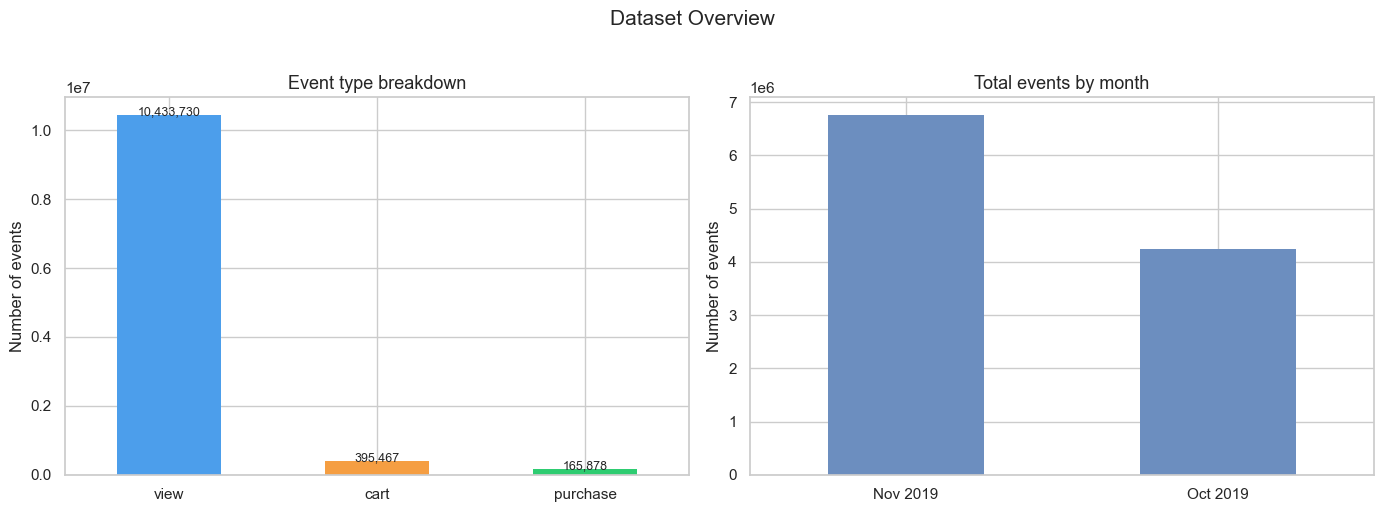

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Event type breakdown
event_counts.plot(kind='bar', ax=axes[0], 
                  color=['#4C9EEB','#F59E42','#2ECC71'],
                  edgecolor='none')
axes[0].set_title('Event type breakdown', fontsize=13)
axes[0].set_ylabel('Number of events')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10000,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontsize=9)

# Chart 2 — Events by month
df.groupby('month_name')['event_type'].count().plot(
    kind='bar', ax=axes[1], color='#6C8EBF', edgecolor='none')
axes[1].set_title('Total events by month', fontsize=13)
axes[1].set_ylabel('Number of events')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Dataset Overview', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('processed/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()